# 미니프로젝트: 회귀 및 분류 모델링 (Vibe Coding)

#### <목표>
Day 2에서 배운 **다중선형회귀, Ridge·Lasso, 로지스틱 회귀, 의사결정나무**를 새로운 제조 데이터셋에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터 (2017.03~2017.09)
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | 다중선형회귀, Ridge, Lasso, 의사결정나무 회귀 |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` (재구성 필요) | 로지스틱 회귀, 의사결정나무 분류 |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 이번에는 제조 공정 데이터를 가지고 회귀와 분류를 모두 다뤄야 합니다. 분석에 필요한 라이브러리를 AI와 상의해서 불러오세요.

In [6]:
# [과제] 회귀 + 분류 공통 분석 라이브러리
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# 그래프 기본 스타일
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_reg.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [7]:
# [과제] 회귀 데이터 불러오기
reg_df = pd.read_csv(os.path.join("dataset", "day2_miniproject_reg.csv"))

# 로드 직후 기본 확인
print("shape:", reg_df.shape)
display(reg_df.head())
reg_df.info()

shape: (3948, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   object 
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed                 3948 non-null   float64
 3   Starch Flow                   3948 non-null   float64
 4   Amina Flow                    3948 non-null   float64
 5   Ore Pulp Flow                 3948 non-null   float64
 6   Ore Pulp pH                   3948 non-null   float64
 7   Ore Pulp Density              3948 non-null   float64
 8   Flotation Column 01 Air Flow  3948 non-null   float64
 9   Flotation Column 02 Air Flow  3948 non-null   float64
 10  Flotation Column 03 Air Flow  3948 non-null   float64
 11  Flotation Column 04 Air Flow  3948 non-null   float64
 12  Flotation Column 05 Air Flow  3948 non-null   float64
 13  Flo

---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 데이터에 대한 이해 없이 모델링을 진행하는 것이 불안합니다. AI와 함께 데이터의 어떤 특성을 먼저 확인해야 하는지 논의하고, 실제로 데이터를 탐색하여 분석에 필요한 인사이트를 도출해 보세요.

In [8]:
# [과제] Value 기반 EDA: 결측치, 데이터 타입, 중복 행 확인

# 1) 결측치 개수 확인
print("[결측치 개수]")
print(reg_df.isna().sum())

# 2) 데이터 타입 확인
print("\n[데이터 타입]")
print(reg_df.dtypes)

# 3) 중복 행 여부 확인
dup_cnt = reg_df.duplicated().sum()
print(f"\n[중복 행 개수] {dup_cnt}")

# 참고: 중복 데이터가 있다면 모델 학습 편향 가능성이 있어 제거 검토
# if dup_cnt > 0:
#     reg_df = reg_df.drop_duplicates().reset_index(drop=True)

[결측치 개수]
date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

[데이터 타입]
date                             object
% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     

### A-1-2) Graph 기반 탐색

**[과제]** 써니는 데이터를 살펴보던 중 변수들이 시간에 따라 수집된 값이라는 사실을 확인했습니다. 이에 따라 시간의 흐름에 따라 각 변수의 값이 어떻게 변화하는지 궁금해졌습니다. AI와 함께 시계열 데이터에 적합한 시각화 방법을 논의하고 변수별 변화를 직접 시각화하여 데이터에서 발견한 특징과 인사이트를 정리해 보세요.

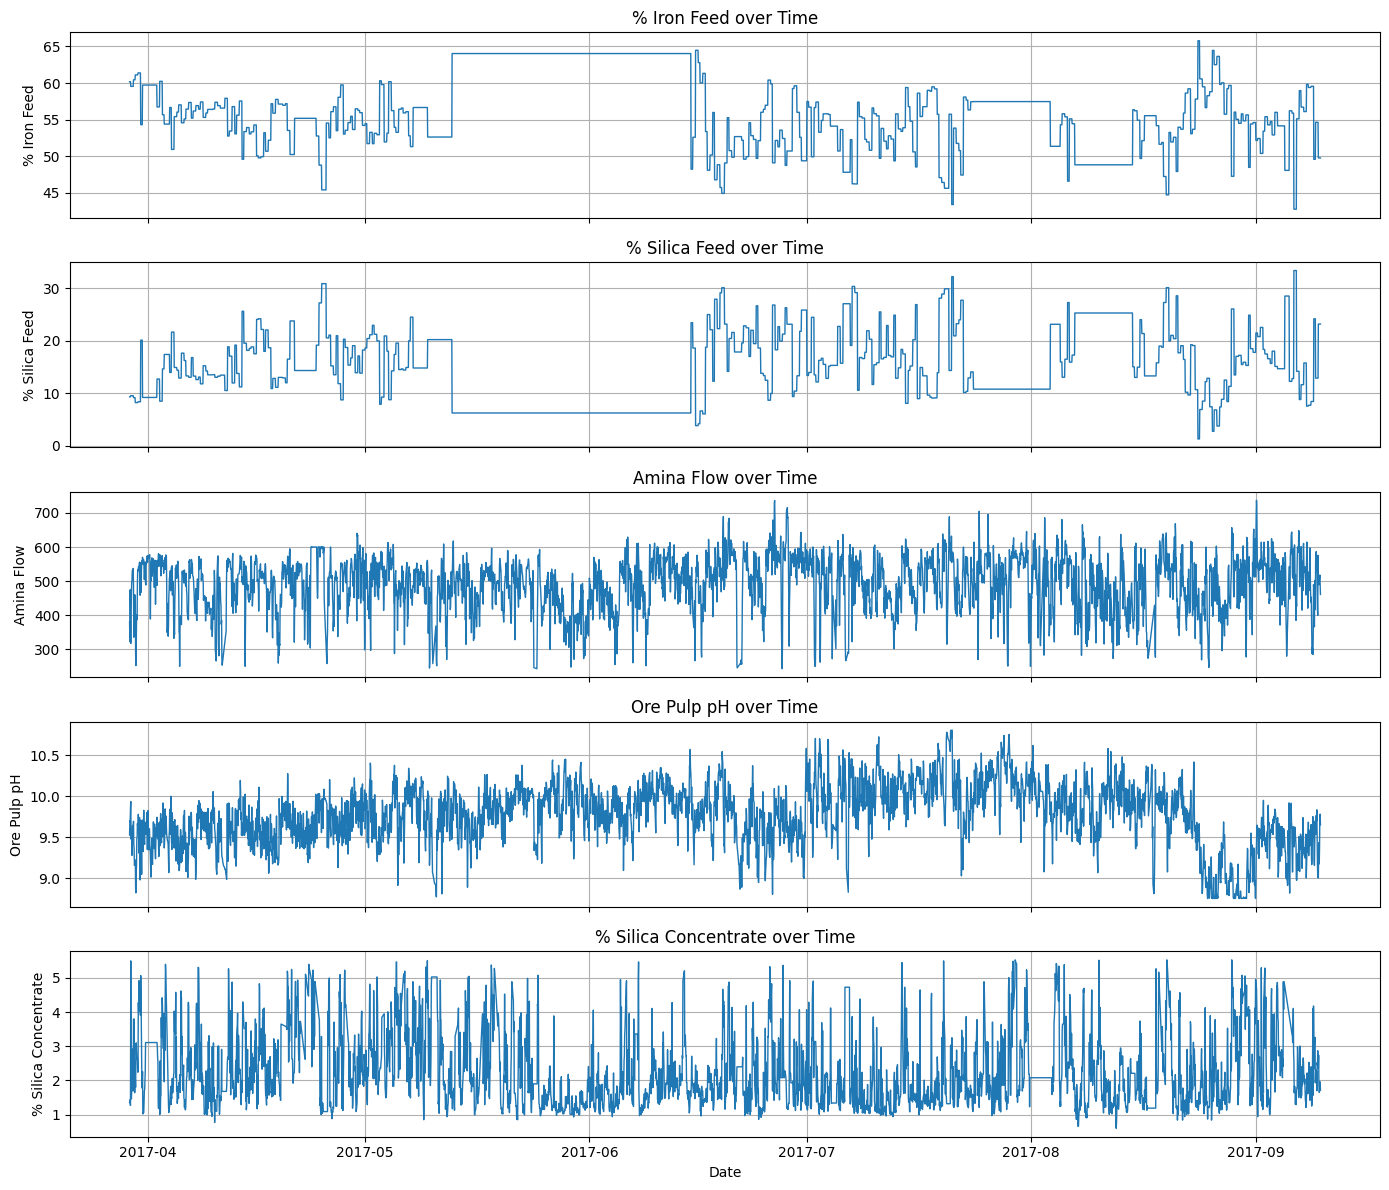

In [9]:
# [과제] 시계열 관점 변수 변화 시각화 (line plot)

# 1) date를 datetime으로 변환하고 시간순 정렬
reg_df["date"] = pd.to_datetime(reg_df["date"])
reg_df = reg_df.sort_values("date").reset_index(drop=True)

# 2) 시계열 추이를 볼 대표 변수 선택
time_cols = [
    "% Iron Feed",
    "% Silica Feed",
    "Amina Flow",
    "Ore Pulp pH",
    "% Silica Concentrate",   # 회귀 타겟
]

# 3) 선그래프로 시간 흐름에 따른 변화 확인
fig, axes = plt.subplots(len(time_cols), 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(time_cols):
    axes[i].plot(reg_df["date"], reg_df[col], linewidth=1)
    axes[i].set_title(f"{col} over Time")
    axes[i].set_ylabel(col)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# 인사이트 정리 가이드:
# - 급격한 스파이크(이상치 후보)가 있는 변수는 무엇인지
# - 장기적으로 상승/하락 추세가 보이는지
# - 타겟(% Silica Concentrate)과 함께 변하는 변수 후보가 보이는지

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

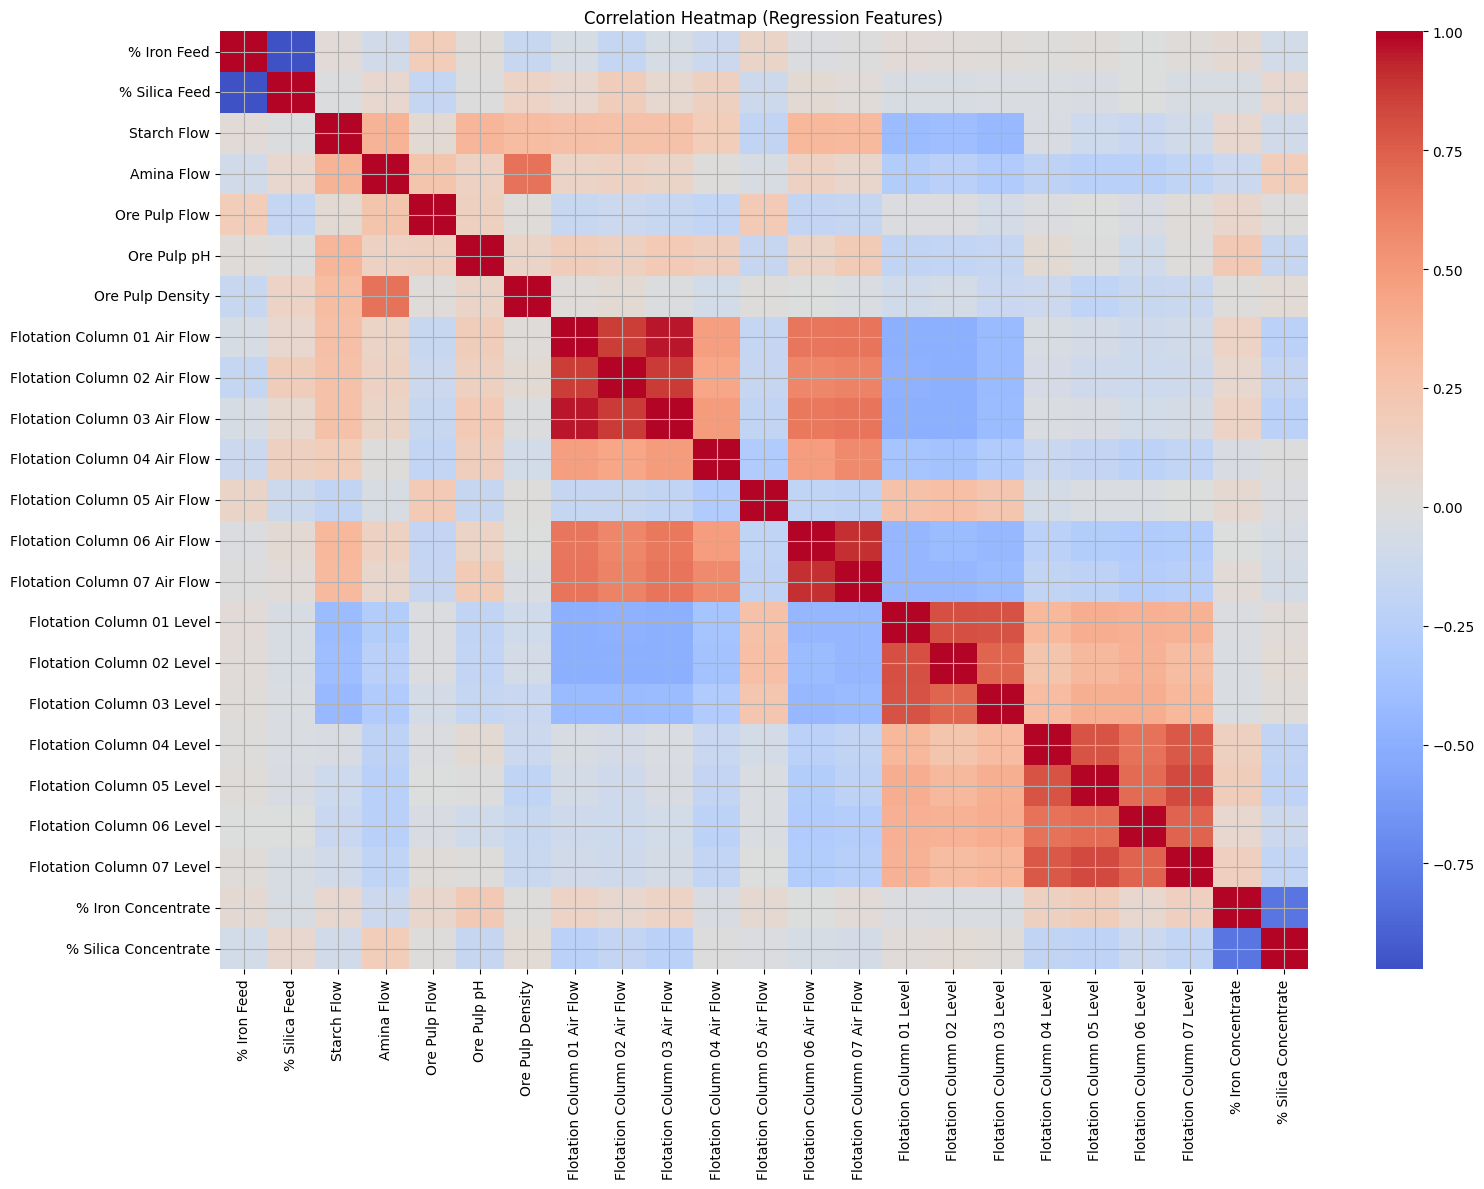

In [10]:
# [과제] 변수 간 상관관계 히트맵 (다중공선성 후보 확인)

# date는 수치형 상관계수 계산에서 제외
num_cols = reg_df.drop(columns=["date"]).select_dtypes(include="number").columns
corr_mat = reg_df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_mat, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Regression Features)")
plt.tight_layout()
plt.show()

# 해석 가이드:
# - 색이 진하고 값이 1 또는 -1에 가까울수록 강한 상관관계
# - |corr| >= 0.9 인 변수쌍은 다중공선성 후보로 검토

In [11]:
corr_mat

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
% Iron Feed,1.000000,-0.972047,0.030933,-0.093785,0.182895,0.014026,-0.148803,-0.049256,-0.163703,-0.048144,...,0.004621,0.033463,0.025516,0.020001,0.011398,0.016096,-0.008925,0.017287,0.054285,-0.085503
% Silica Feed,-0.972047,1.000000,-0.014637,0.081443,-0.170492,-0.000599,0.126092,0.077022,0.175415,0.068119,...,0.023315,-0.043095,-0.044265,-0.028824,-0.031673,-0.038061,-0.008252,-0.040091,-0.042923,0.082566
Starch Flow,0.030933,-0.014637,1.000000,0.365694,0.049626,0.352483,0.299222,0.280294,0.275554,0.271855,...,0.316547,-0.410414,-0.397326,-0.425630,-0.035987,-0.111110,-0.141156,-0.089381,0.076231,-0.089539
Amina Flow,-0.093785,0.081443,0.365694,1.000000,0.249450,0.131629,0.673053,0.119217,0.134992,0.108100,...,0.086112,-0.276929,-0.232592,-0.293718,-0.216308,-0.245831,-0.242658,-0.200239,-0.125858,0.180346
Ore Pulp Flow,0.182895,-0.170492,0.049626,0.249450,1.000000,0.149025,0.019878,-0.151049,-0.131317,-0.154248,...,-0.159743,-0.017065,-0.022417,-0.077078,-0.017814,-0.002605,-0.037042,0.015238,0.090560,0.012050
Ore Pulp pH,0.014026,-0.000599,0.352483,0.131629,0.149025,1.000000,0.108475,0.169244,0.152348,0.201580,...,0.191923,-0.189077,-0.180673,-0.166461,0.050258,0.004286,-0.099951,0.013752,0.207042,-0.160985
Ore Pulp Density,-0.148803,0.126092,0.299222,0.673053,0.019878,0.108475,1.000000,0.015619,0.049135,-0.013155,...,-0.031414,-0.101334,-0.073317,-0.142755,-0.131989,-0.198394,-0.153293,-0.139310,0.010359,0.040395
Flotation Column 01 Air Flow,-0.049256,0.077022,0.280294,0.119217,-0.151049,0.169244,0.015619,1.000000,0.861870,0.958320,...,0.661433,-0.490638,-0.493095,-0.423260,-0.046686,-0.072727,-0.106941,-0.092356,0.126028,-0.226252
Flotation Column 02 Air Flow,-0.163703,0.175415,0.275554,0.134992,-0.131317,0.152348,0.049135,0.861870,1.000000,0.874899,...,0.600869,-0.485804,-0.496208,-0.421688,-0.068181,-0.102050,-0.110822,-0.102041,0.082481,-0.174562
Flotation Column 03 Air Flow,-0.048144,0.068119,0.271855,0.108100,-0.154248,0.201580,-0.013155,0.958320,0.874899,1.000000,...,0.662155,-0.490942,-0.490122,-0.416977,-0.025896,-0.038339,-0.080939,-0.059165,0.129493,-0.226228


---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델링 전에 입력변수들을 점검해 보기로 했습니다. AI와 함께 각 변수의 의미를 확인하고, date와 같이 사용 여부를 고민해야 하는 변수나 데이터 누수를 유발할 수 있는 변수가 없는지 검토하고 제거해보세요.

In [12]:
# [과제] 불필요한 변수 제거 및 결측치 확인

# 1) 제거 대상
# - % Iron Concentrate: 타겟(% Silica Concentrate)과 동시에 측정된 최종 정광 결과값
#   -> 입력으로 쓰면 데이터 누수(Data Leakage) 가능성
# - date: 시각화/분할에는 사용하지만, 모델 입력으로 직접 넣지 않음
drop_cols = ["% Iron Concentrate", "date"]

reg_model_df = reg_df.drop(columns=drop_cols)

# 2) 결측치 재확인
print("[결측치 개수]")
print(reg_model_df.isna().sum())

# 3) 모델링용 데이터 shape 확인
print("\n모델링용 데이터 shape:", reg_model_df.shape)
print("타겟 변수:", "% Silica Concentrate")


[결측치 개수]
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Silica Concentrate            0
dtype: int64

모델링용 데이터 shape: (3948, 22)
타겟 변수: % Silica Concentrate


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하고자 합니다. 또한 데이터가 시간에 따라 수집되었다는 점을 고려하여 어떤 방식으로 학습 데이터와 테스트 데이터를 나누는 것이 적절할지 AI와 상의한 후, 데이터를 분할해 보세요.

In [14]:
# [과제] 입출력 변수 분리 + 시계열 기준 train/test 분할

# 1) 입력(X) / 타겟(y) 분리
X_reg = reg_model_df.drop(columns=["% Silica Concentrate"])
y_reg = reg_model_df["% Silica Concentrate"]

# 2) 시계열 데이터는 시간순 분할 (앞 70% train, 뒤 30% test)
#    shuffle=True로 무작위 섞으면 미래 정보가 학습에 섞여 평가가 부풀려질 수 있음
split_idx = int(len(reg_model_df) * 0.7)

X_reg_train = X_reg.iloc[:split_idx]
X_reg_test = X_reg.iloc[split_idx:]
y_reg_train = y_reg.iloc[:split_idx]
y_reg_test = y_reg.iloc[split_idx:]

print("Train shape:", X_reg_train.shape, y_reg_train.shape)
print("Test shape :", X_reg_test.shape, y_reg_test.shape)


Train shape: (2763, 21) (2763,)
Test shape : (1185, 21) (1185,)


### A-2-3) 변수 스케일링 및 인코딩

**[과제]** 써니는 변수마다 값의 범위와 단위가 다를 경우 스케일링이 필요하고 범주형 변수의 경우 숫자로 바꿔주는 인코딩이 필요할 수 있다는 것을 배웠습니다. AI와 함께 적절한 스케일링 및 인코딩 기법을 선택하여 적용해 보세요.

In [15]:
# [과제] 변수 스케일링 (회귀 데이터는 수치형만 존재 -> 인코딩 불필요)

scaler_reg = StandardScaler()

# 데이터 누수 방지: X_train에만 fit, train/test 모두 transform
X_reg_train_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_reg_train),
    columns=X_reg_train.columns,
    index=X_reg_train.index,
)
X_reg_test_scaled = pd.DataFrame(
    scaler_reg.transform(X_reg_test),
    columns=X_reg_test.columns,
    index=X_reg_test.index,
)

print("스케일링 후 train 평균(0에 가까움):")
print(X_reg_train_scaled.mean().round(3).head())
print("\n스케일링 후 train 표준편차(1에 가까움):")
print(X_reg_train_scaled.std().round(3).head())


스케일링 후 train 평균(0에 가까움):
% Iron Feed      0.0
% Silica Feed   -0.0
Starch Flow      0.0
Amina Flow      -0.0
Ore Pulp Flow    0.0
dtype: float64

스케일링 후 train 표준편차(1에 가까움):
% Iron Feed      1.0
% Silica Feed    1.0
Starch Flow      1.0
Amina Flow       1.0
Ore Pulp Flow    1.0
dtype: float64


---
## A-3) 모델링

### A-3-1) 다중선형회귀

**[과제]** 써니는 다중선형회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 공정 변수가 실리카 비율에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수를 변수명과 함께 정리해 보세요.

In [ ]:
# [과제] 다중선형회귀 학습 및 회귀 계수(coef_) 확인

LR_model = LinearRegression()
LR_model.fit(X_reg_train_scaled, y_reg_train)

# 회귀 계수(beta)를 변수명과 함께 정리 (절대값 기준 정렬)
coef_df = pd.DataFrame({
    "feature": X_reg_train_scaled.columns,
    "coef": LR_model.coef_,
    "abs_coef": np.abs(LR_model.coef_),
}).sort_values("abs_coef", ascending=False)

print("[다중선형회귀] 회귀 계수 (영향력 큰 순)")
print(coef_df.drop(columns=["abs_coef"]))

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x="abs_coef", y="feature")
plt.title("Linear Regression - |Coefficient| by Feature")
plt.xlabel("|coef|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 참고: 스케일링 후 coef_의 절대값이 클수록 타겟에 미치는 영향이 큼
#       feature_importances_는 트리 모델용, 선형회귀는 coef_ 사용


### A-3-2) Ridge/Lasso 회귀

**[과제]** 써니는 A-1에서 확인한 다중공선성 문제가 정규화(Regularization) 기법을 통해 완화될 수 있는지 확인해보려고 합니다. Ridge 회귀와 Lasso 회귀 모델을 학습하고 각 모델의 예측 성능과 계수 변화를 함께 분석하여, 해당 데이터에 가장 적절한 모델을 선택하세요.

In [ ]:
# [과제] Ridge / Lasso 회귀 학습 및 성능·계수 비교

ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.01, max_iter=10000)

ridge_model.fit(X_reg_train_scaled, y_reg_train)
lasso_model.fit(X_reg_train_scaled, y_reg_train)

# 예측
lr_pred = LR_model.predict(X_reg_test_scaled)
ridge_pred = ridge_model.predict(X_reg_test_scaled)
lasso_pred = lasso_model.predict(X_reg_test_scaled)

# 성능 비교
reg_perf = pd.DataFrame([
    {"Model": "LinearRegression", "RMSE": np.sqrt(mean_squared_error(y_reg_test, lr_pred)), "R2": r2_score(y_reg_test, lr_pred)},
    {"Model": "Ridge", "RMSE": np.sqrt(mean_squared_error(y_reg_test, ridge_pred)), "R2": r2_score(y_reg_test, ridge_pred)},
    {"Model": "Lasso", "RMSE": np.sqrt(mean_squared_error(y_reg_test, lasso_pred)), "R2": r2_score(y_reg_test, lasso_pred)},
]).sort_values("R2", ascending=False)

print("[회귀 모델 성능 비교]")
print(reg_perf.round(4))

# 계수 비교 (Lasso는 일부 계수가 0이 될 수 있음)
coef_compare = pd.DataFrame({
    "feature": X_reg_train_scaled.columns,
    "Linear": LR_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
})
coef_compare["abs_Lasso"] = np.abs(coef_compare["Lasso"])
coef_compare = coef_compare.sort_values("abs_Lasso", ascending=False)

print("\n[계수 비교]")
print(coef_compare.drop(columns=["abs_Lasso"]))

# Lasso에서 0이 된 변수 개수
zero_cnt = (coef_compare["Lasso"] == 0).sum()
print(f"\nLasso 계수가 0인 변수 개수: {zero_cnt}")

# 해석: Ridge는 계수를 줄이고, Lasso는 변수 선택(0 계수) 효과가 있음

### A-3-3) 의사결정나무 회귀

**[과제]** 써니는 공정 변수와 % Silica Concentrate 사이에 선형 회귀만으로는 설명하기 어려운 비선형 관계가 존재할 수 있다고 생각했습니다. AI와 함께 회귀 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

In [ ]:
# [과제] 의사결정나무 회귀 학습 및 트리 시각화
from sklearn import tree

# max_depth로 트리 깊이 제한 -> 과적합 방지
dt_reg = DecisionTreeRegressor(random_state=0, max_depth=5)
dt_reg.fit(X_reg_train, y_reg_train)

dt_reg_pred = dt_reg.predict(X_reg_test)

print("[DecisionTree Regressor] Test 성능")
print("RMSE:", round(np.sqrt(mean_squared_error(y_reg_test, dt_reg_pred)), 4))
print("R2  :", round(r2_score(y_reg_test, dt_reg_pred), 4))

# 트리 구조 시각화 (해석을 위해 상위 depth만 표시)
plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt_reg,
    feature_names=X_reg_train.columns,
    filled=True,
    fontsize=8,
    max_depth=3,
)
plt.title("Decision Tree Regressor (max_depth=5, view_depth=3)")
plt.tight_layout()
plt.show()

# 해석: 루트/상위 노드의 분할 변수가 주요 공정 변수 후보

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 지금까지 만든 회귀 모델들(다중선형회귀, Ridge, Lasso, 의사결정나무)의 성능(RMSE, R-squared 등)을 표나 그래프로 한눈에 비교하고 싶습니다. AI와 상의해서 종합 비교 자료를 만들어 보세요.

In [ ]:
# [과제] 회귀 모델 종합 성능 비교 (기준: R2, 보조: RMSE)

reg_summary = pd.DataFrame([
    {
        "Model": "LinearRegression",
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, lr_pred)),
        "R2": r2_score(y_reg_test, lr_pred),
    },
    {
        "Model": "Ridge",
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, ridge_pred)),
        "R2": r2_score(y_reg_test, ridge_pred),
    },
    {
        "Model": "Lasso",
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, lasso_pred)),
        "R2": r2_score(y_reg_test, lasso_pred),
    },
    {
        "Model": "DecisionTree",
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, dt_reg_pred)),
        "R2": r2_score(y_reg_test, dt_reg_pred),
    },
]).sort_values("R2", ascending=False)

print("[회귀 모델 종합 비교]")
print(reg_summary.round(4))

# R2 비교 그래프
plt.figure(figsize=(8, 4))
sns.barplot(data=reg_summary, x="Model", y="R2")
plt.title("Regression Models - R2 Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# RMSE 비교 그래프 (낮을수록 좋음)
plt.figure(figsize=(8, 4))
sns.barplot(data=reg_summary.sort_values("RMSE"), x="Model", y="RMSE")
plt.title("Regression Models - RMSE Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_reg_model_name = reg_summary.iloc[0]["Model"]
print("최고 성능 회귀 모델(R2 기준):", best_reg_model_name)

**[과제]** 써니는 선형 계열 모델의 회귀 계수와 의사결정나무의 변수 중요도를 함께 비교해서, 어떤 공정 변수가 모델 종류와 관계없이 일관되게 중요하게 나타나는지 확인하고 싶습니다. AI와 상의해서 비교 시각화를 만들어 보세요.

In [ ]:
# [과제] 선형 계수(coef_) vs 트리 변수 중요도(feature_importances_) 비교

importance_compare = pd.DataFrame({
    "feature": X_reg_train_scaled.columns,
    "Ridge_abs_coef": np.abs(ridge_model.coef_),
    "Lasso_abs_coef": np.abs(lasso_model.coef_),
    "Tree_importance": dt_reg.feature_importances_,
})

# 비교를 위해 각 지표를 0~1로 정규화
for col in ["Ridge_abs_coef", "Lasso_abs_coef", "Tree_importance"]:
    max_val = importance_compare[col].max()
    if max_val > 0:
        importance_compare[col + "_norm"] = importance_compare[col] / max_val

print("[변수 영향력 비교 (정규화)]")
print(
    importance_compare[
        ["feature", "Ridge_abs_coef_norm", "Lasso_abs_coef_norm", "Tree_importance_norm"]
    ].sort_values("Tree_importance_norm", ascending=False)
)

# 시각화: 상위 10개 변수
plot_df = importance_compare.sort_values("Tree_importance", ascending=False).head(10)
plot_melt = plot_df.melt(
    id_vars="feature",
    value_vars=["Ridge_abs_coef_norm", "Lasso_abs_coef_norm", "Tree_importance_norm"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_melt, x="score", y="feature", hue="metric")
plt.title("Top 10 Features - Linear coef vs Tree importance")
plt.tight_layout()
plt.show()

# 해석: 세 모델에서 공통으로 높게 나오는 변수가 핵심 공정 변수 후보

**[과제]** 써니는 여러 회귀 모델 중 가장 우수한 모델을 발견했지만, 아직 성능을 더 개선할 여지가 있다고 생각했습니다. AI와 함께 어떤 하이퍼파라미터를 조정해야 할지 논의하고, 적절한 탐색 범위를 설정하여 모델 성능을 최대한 높여보세요.

In [ ]:
# [과제] 회귀 모델 하이퍼파라미터 튜닝 (GridSearchCV)
from sklearn.model_selection import TimeSeriesSplit

# 시계열 데이터이므로 TimeSeriesSplit 사용 (일반 KFold는 시간 순서가 섞여 부정확할 수 있음)
tscv = TimeSeriesSplit(n_splits=3)

# Ridge: alpha 탐색
ridge_param_grid = {"alpha": np.logspace(-2, 2, 15)}
grid_ridge = GridSearchCV(Ridge(), ridge_param_grid, cv=tscv, scoring="r2")
grid_ridge.fit(X_reg_train_scaled, y_reg_train)
best_ridge = grid_ridge.best_estimator_
best_ridge_pred = best_ridge.predict(X_reg_test_scaled)

# Lasso: alpha 탐색
lasso_param_grid = {"alpha": np.logspace(-4, 0, 15)}
grid_lasso = GridSearchCV(Lasso(max_iter=20000), lasso_param_grid, cv=tscv, scoring="r2")
grid_lasso.fit(X_reg_train_scaled, y_reg_train)
best_lasso = grid_lasso.best_estimator_
best_lasso_pred = best_lasso.predict(X_reg_test_scaled)

# DecisionTree: max_depth + min_samples_leaf 탐색
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=0), dt_param_grid, cv=tscv, scoring="r2")
grid_dt.fit(X_reg_train, y_reg_train)
best_dt = grid_dt.best_estimator_
best_dt_pred = best_dt.predict(X_reg_test)

print("[튜닝 결과 요약]")
print("Ridge best:", grid_ridge.best_params_, "| CV R2:", round(grid_ridge.best_score_, 4), "| Test R2:", round(r2_score(y_reg_test, best_ridge_pred), 4))
print("Lasso best:", grid_lasso.best_params_, "| CV R2:", round(grid_lasso.best_score_, 4), "| Test R2:", round(r2_score(y_reg_test, best_lasso_pred), 4))
print("DT best:", grid_dt.best_params_, "| CV R2:", round(grid_dt.best_score_, 4), "| Test R2:", round(r2_score(y_reg_test, best_dt_pred), 4))

# 튜닝 전후 Test R2 비교
tuned_summary = pd.DataFrame([
    {"Model": "Ridge (before)", "Test_R2": r2_score(y_reg_test, ridge_pred), "Test_RMSE": np.sqrt(mean_squared_error(y_reg_test, ridge_pred))},
    {"Model": "Ridge (tuned)", "Test_R2": r2_score(y_reg_test, best_ridge_pred), "Test_RMSE": np.sqrt(mean_squared_error(y_reg_test, best_ridge_pred))},
    {"Model": "Lasso (before)", "Test_R2": r2_score(y_reg_test, lasso_pred), "Test_RMSE": np.sqrt(mean_squared_error(y_reg_test, lasso_pred))},
    {"Model": "Lasso (tuned)", "Test_R2": r2_score(y_reg_test, best_lasso_pred), "Test_RMSE": np.sqrt(mean_squared_error(y_reg_test, best_lasso_pred))},
    {"Model": "DecisionTree (before)", "Test_R2": r2_score(y_reg_test, dt_reg_pred), "Test_RMSE": np.sqrt(mean_squared_error(y_reg_test, dt_reg_pred))},
    {"Model": "DecisionTree (tuned)", "Test_R2": r2_score(y_reg_test, best_dt_pred), "Test_RMSE": np.sqrt(mean_squared_error(y_reg_test, best_dt_pred))},
])

print("\n[튜닝 전후 Test 성능 비교]")
print(tuned_summary.round(4))

# 해석 가이드:
# - 튜닝 후에도 크게 안 오를 수 있음 (이미 baseline이 괜찮거나, alpha가 원래 grid 안에 있었거나)
# - CV R2와 Test R2가 다를 수 있음 (특히 시계열에서는 test가 미래 구간이라 더 어려움)
# - DecisionTree는 max_depth를 줄이면(예: 3) 과적합이 줄어 test 성능이 소폭 개선되는 경우가 많음

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 `dataset/day2_miniproject_cls.csv` 파일을 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [ ]:
# [과제] 분류 데이터 불러오기
cls_df = pd.read_csv(os.path.join("dataset", "day2_miniproject_cls.csv"))

# 로드 직후 기본 확인
print("shape:", cls_df.shape)
display(cls_df.head())
cls_df.info()

---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 타겟 변수의 분포가 어떻게 구성되어 있는지 궁금해졌습니다. AI와 함께 적절한 시각화 기법을 선택하여 타겟 변수의 빈도와 비율을 분석하고, 분석 결과를 바탕으로 향후 모델링 과정에서 고려해야 할 사항이 무엇인지 생각해 보세요.

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scratch를 분류 타겟(0/1)으로 사용하기로 했습니다. 이때 나머지 결함 유형 컬럼(Pastry, Z_Scratch, Stains, Dirtiness, Bumps, Other_Faults)이 타겟과 어떤 관계를 가지는지 궁금해졌습니다. AI와 함께 각 변수의 의미와 타겟과의 관계를 분석하고, 모델링 과정에서 해당 변수들을 사용하는 것이 적절한지 판단한 뒤 필요한 전처리를 수행해 보세요.

### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 결측치를 확인한 후 모델링을 위한 데이터를 준비하고자 합니다. AI와 함께 변수별 특성을 고려하여 적절한 결측치 처리 방법을 적용하고, 분류 모델 학습에 적합한 방식으로 학습 데이터와 테스트 데이터를 분할해 보세요.

### B-2-3) 변수 스케일링

**[과제]** 써니는 데이터셋에 수치형 변수와 범주형 변수가 함께 존재한다는 점을 확인했습니다. AI와 함께 각 변수의 특성과 분포를 살펴보고, 스케일링이 필요한 변수를 판단한 뒤 적절한 스케일링 기법을 선택하여 적용해 보세요.

---
## B-3) 모델링

### B-3-1) 로지스틱 회귀

**[과제]** 써니는 로지스틱 회귀 모델을 학습시키고, 회귀 계수를 통해 어떤 변수가 K_Scatch 여부에 큰 영향을 주는지 확인하려고 합니다. 모델을 학습하고 회귀 계수의 절대값 기준으로 변수 영향력을 정리해 보세요.

### B-3-2) 의사결정나무 분류

**[과제]** 써니는 의사결정나무를 활용해 K_Scratch가 어떤 변수와 기준값에 의해 분류되는지 직관적으로 이해하고자 합니다. AI와 함께 분류 나무 모델을 구축하고 학습된 트리를 시각화하여 주요 분할 기준과 의사결정 과정을 해석해 보세요.

---
## B-4) 테스트 데이터 예측

**[과제]** 써니는 로지스틱 회귀와 의사결정나무 분류 모델로 테스트 데이터에 대한 예측을 수행하고, Accuracy·Precision·Recall·F1-score와 혼동행렬을 함께 비교하려고 합니다. AI와 상의해서 두 모델의 예측과 성능 지표를 한 번에 뽑을 수 있도록 코드를 작성해 보세요.

---
## B-5) 모델 고도화

**[과제]** 써니는 분류 모델링 결과를 살펴보며 클래스 불균형이 모델 성능에 영향을 줄 수 있다고 생각했습니다. AI와 함께 이를 해결할 수 있는 로지스틱 회귀와 분류 나무 각각에 적합한 하이퍼파라미터와 튜닝 방법을 탐색하고, 최적의 파라미터를 찾아 모델을 다시 학습해 보세요. 이후 성능이 얼마나 개선되었는지 비교해 보세요.